In [1]:
</>PYTHON

SyntaxError: invalid syntax (4294395157.py, line 1)

In [4]:
print("MY FIRST AI JOURNEY BEGINS")


MY FIRST AI JOURNEY BEGINS


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("/content/IBM.csv")

In [10]:
df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


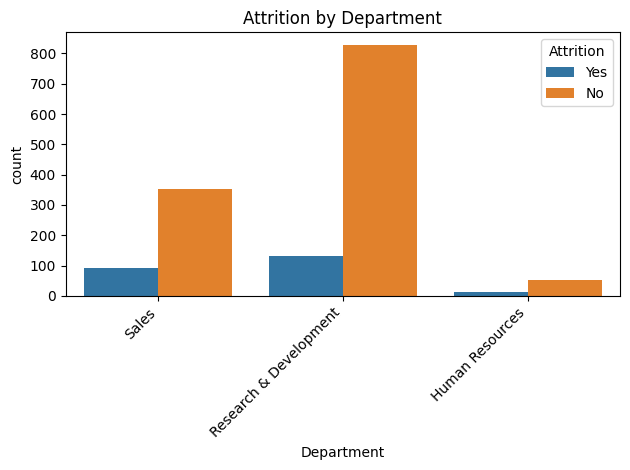

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.728571,6502.931293,2.693197,2.761224,7.008163
std,9.135373,8.106864,1.024165,1.093082,1.102846,4707.956783,2.498009,0.706476,6.126525
min,18.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,2911.000000,1.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,4919.000000,2.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,4.000000,4.000000,8379.000000,4.000000,3.000000,9.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,19999.000000,9.000000,4.000000,40.000000


In [13]:
df.isnull().sum()

,0
Age,0
Attrition,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
JobSatisfaction,0
MaritalStatus,0
MonthlyIncome,0


In [15]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


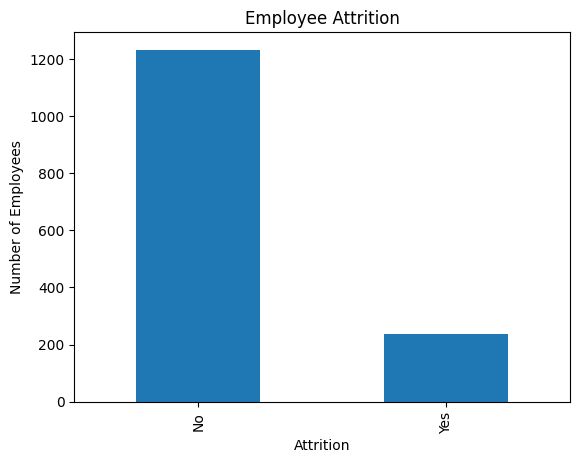

In [16]:
import matplotlib.pyplot as plt

df["Attrition"].value_counts().plot(kind="bar")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.title("Employee Attrition")
plt.show()

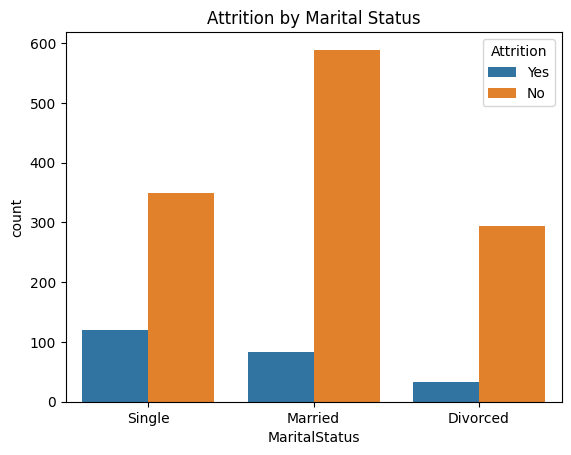

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title('Attrition by Marital Status')
plt.show()

In [18]:
print(df.columns)

Index(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'Education',
       'EducationField', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')


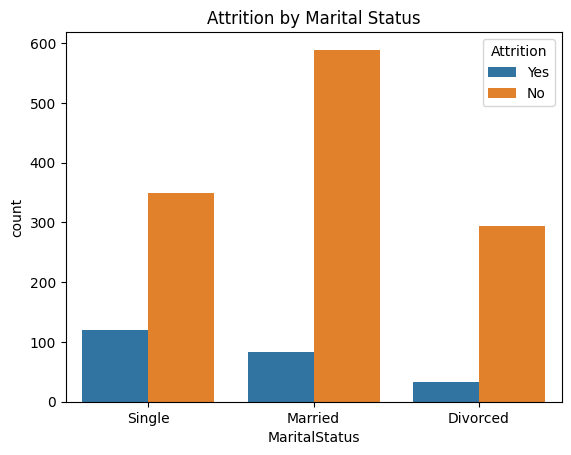

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title('Attrition by Marital Status')
plt.show()

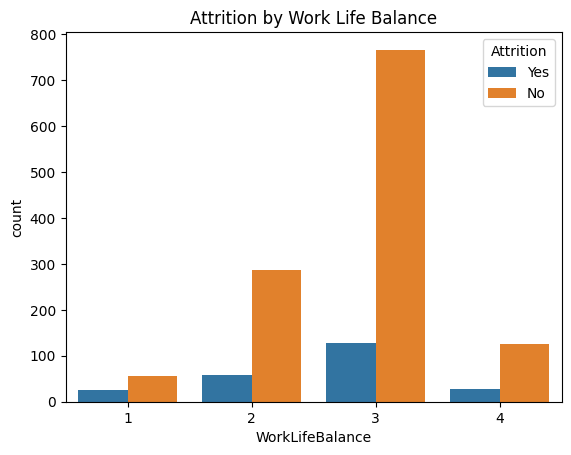

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title('Attrition by Work Life Balance')
plt.show()

### Converting Categorical Features to Numerical

Many machine learning models require numerical input. Here, we'll convert categorical columns (like `Attrition`, `Department`, `MaritalStatus`, etc.) into numerical representations using `LabelEncoder`.

In [23]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the DataFrame to avoid modifying the original 'df' if needed later
df_encoded = df.copy()

# Identify categorical columns (excluding numerical ones and 'Attrition' for now, as it's the target)
categorical_cols = [col for col in df_encoded.columns if df_encoded[col].dtype == 'object']

# Initialize LabelEncoder
label_encoders = {}
for col in categorical_cols:
    if col != 'Attrition': # Attrition is handled separately if it's the target variable
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le # Store encoder for inverse transformation if needed

# Display the first few rows of the encoded DataFrame and its info to verify changes
display(df_encoded.head())
print(df_encoded.info())

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,2,1,2,1,2,4,2,5993,8,1,6
1,49,No,1,8,1,1,3,2,1,5130,1,3,10
2,37,Yes,1,2,2,4,4,3,2,2090,6,3,0
3,33,No,1,3,4,1,4,3,1,2909,1,3,8
4,27,No,1,2,1,3,1,2,1,3468,9,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1470 non-null   int64 
 1   Attrition                1470 non-null   object
 2   Department               1470 non-null   int64 
 3   DistanceFromHome         1470 non-null   int64 
 4   Education                1470 non-null   int64 
 5   EducationField           1470 non-null   int64 
 6   EnvironmentSatisfaction  1470 non-null   int64 
 7   JobSatisfaction          1470 non-null   int64 
 8   MaritalStatus            1470 non-null   int64 
 9   MonthlyIncome            1470 non-null   int64 
 10  NumCompaniesWorked       1470 non-null   int64 
 11  WorkLifeBalance          1470 non-null   int64 
 12  YearsAtCompany           1470 non-null   int64 
dtypes: int64(12), object(1)
memory usage: 149.4+ KB
None


### Separate Features and Target Variable

Now we'll split our `df_encoded` DataFrame into features (X) and the target variable (y). The 'Attrition' column will be the target variable.

In [24]:
# Define features (X) and target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Display the shapes of X and y to confirm the split
print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

# Display the first few rows of X and y
display(X.head())
display(y.head())

Shape of X (features): (1470, 12)
Shape of y (target): (1470,)


,Age,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,2,1,2,1,2,4,2,5993,8,1,6
1,49,1,8,1,1,3,2,1,5130,1,3,10
2,37,1,2,2,4,4,3,2,2090,6,3,0
3,33,1,3,4,1,4,3,1,2909,1,3,8
4,27,1,2,1,3,1,2,1,3468,9,3,2


,Attrition
0,Yes
1,No
2,Yes
3,No
4,No


### Split Data into Training and Testing Sets

To evaluate the performance of our model, we'll split the data into training and testing sets. The training set will be used to train the model, and the testing set will be used to evaluate how well it generalizes to new, unseen data.

In [25]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Display the shapes of the new sets to confirm the split
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1029, 12)
Shape of X_test: (441, 12)
Shape of y_train: (1029,)
Shape of y_test: (441,)


### Encode Target Variable

Since our target variable 'Attrition' is still categorical ('Yes'/'No'), we need to convert it into a numerical format (0s and 1s) for model training.

In [26]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable 'Attrition'
le_y = LabelEncoder()
y_train_encoded = le_y.fit_transform(y_train)
y_test_encoded = le_y.transform(y_test)

print("Original y_train values:", y_train.unique())
print("Encoded y_train values:", np.unique(y_train_encoded))
print("Original y_test values:", y_test.unique())
print("Encoded y_test values:", np.unique(y_test_encoded))

Original y_train values: ['No' 'Yes']
Encoded y_train values: [0 1]
Original y_test values: ['No' 'Yes']
Encoded y_test values: [0 1]


### Model Training and Evaluation

Now, we'll train a classification model (RandomForestClassifier) on our training data and evaluate its performance using accuracy score and a confusion matrix on the test data.

Model Accuracy: 0.8322


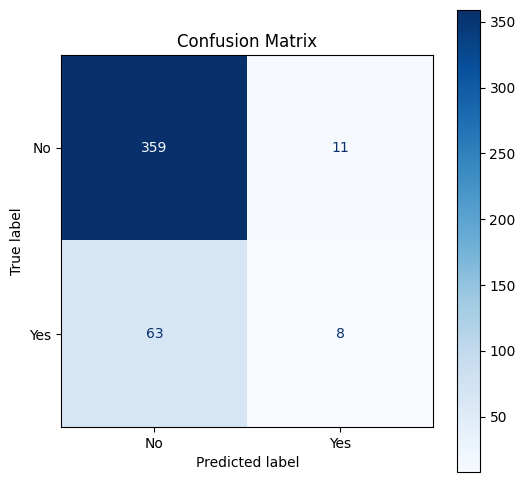

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train_encoded)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate and display the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_y.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()

In [28]:
from sklearn.metrics import classification_report

# Generate and print the classification report
report = classification_report(y_test_encoded, y_pred, target_names=le_y.classes_)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.97      0.91       370
         Yes       0.42      0.11      0.18        71

    accuracy                           0.83       441
   macro avg       0.64      0.54      0.54       441
weighted avg       0.78      0.83      0.79       441



In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the sorted feature importances
print("Feature Importances (Top 10):\n")
display(features_df.head(10))

Feature Importances (Top 10):



,Feature,Importance
8,MonthlyIncome,0.181691
0,Age,0.143511
11,YearsAtCompany,0.122887
2,DistanceFromHome,0.104692
9,NumCompaniesWorked,0.082626
4,EducationField,0.057593
6,JobSatisfaction,0.057216
5,EnvironmentSatisfaction,0.055561
3,Education,0.053774
10,WorkLifeBalance,0.052550


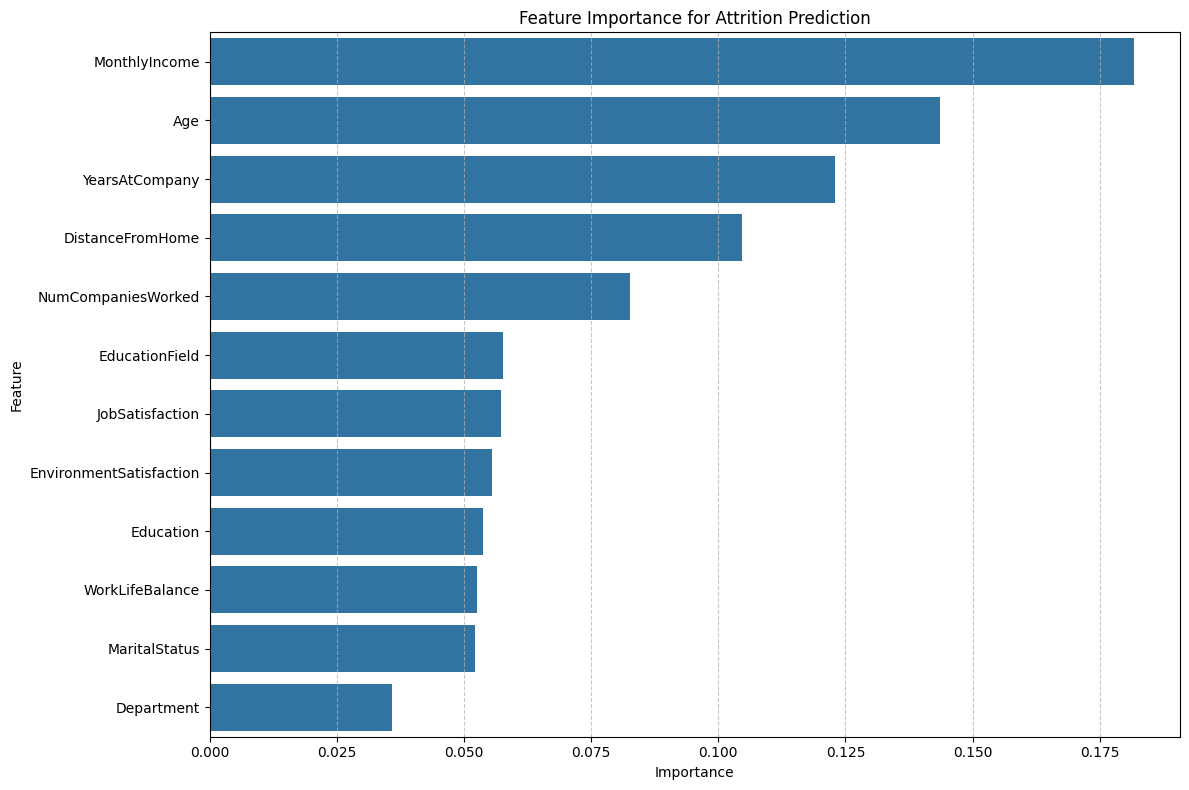

In [30]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance for Attrition Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()